# ResumeIQ - AI Resume Screening System

## Notebook 06: Model Explainability & Error Analysis

### Objective

Evaluate the optimized machine learning model using different metrics and visualize its performance.

### Topics Covered

- Classification Report
- Confusion Matrix
- Error Analysis
- Important TF-IDF Features

In [1]:
import joblib
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
model = joblib.load(r"C:\Users\geeth\OneDrive\Desktop\ResumeIQ-AI-Resume-Screening-System\trained_models\optimized_resume_classifier.pkl")

tfidf = joblib.load(r"C:\Users\geeth\OneDrive\Desktop\ResumeIQ-AI-Resume-Screening-System\trained_models\tfidf_vectorizer.pkl")

label_encoder = joblib.load(r"C:\Users\geeth\OneDrive\Desktop\ResumeIQ-AI-Resume-Screening-System\trained_models\label_encoder.pkl")

X_test = joblib.load(r"C:\Users\geeth\OneDrive\Desktop\ResumeIQ-AI-Resume-Screening-System\trained_models\X_test.pkl")

y_test = joblib.load(r"C:\Users\geeth\OneDrive\Desktop\ResumeIQ-AI-Resume-Screening-System\trained_models\y_test.pkl")

In [3]:
predictions = model.predict(X_test)

In [5]:
print(classification_report(
    y_test,
    predictions,
    target_names=label_encoder.classes_
))

                           precision    recall  f1-score   support

                 Advocate       1.00      1.00      1.00         4
                     Arts       1.00      1.00      1.00         7
       Automation Testing       0.83      1.00      0.91         5
               Blockchain       1.00      1.00      1.00         8
         Business Analyst       1.00      1.00      1.00         6
           Civil Engineer       1.00      1.00      1.00         5
             Data Science       1.00      1.00      1.00         8
                 Database       1.00      1.00      1.00         7
          DevOps Engineer       1.00      0.91      0.95        11
         DotNet Developer       1.00      1.00      1.00         5
            ETL Developer       1.00      1.00      1.00         8
   Electrical Engineering       1.00      1.00      1.00         6
                       HR       1.00      1.00      1.00         9
                   Hadoop       1.00      1.00      1.00     

In [6]:
print(classification_report(
    y_test,
    predictions,
    target_names=label_encoder.classes_
))

                           precision    recall  f1-score   support

                 Advocate       1.00      1.00      1.00         4
                     Arts       1.00      1.00      1.00         7
       Automation Testing       0.83      1.00      0.91         5
               Blockchain       1.00      1.00      1.00         8
         Business Analyst       1.00      1.00      1.00         6
           Civil Engineer       1.00      1.00      1.00         5
             Data Science       1.00      1.00      1.00         8
                 Database       1.00      1.00      1.00         7
          DevOps Engineer       1.00      0.91      0.95        11
         DotNet Developer       1.00      1.00      1.00         5
            ETL Developer       1.00      1.00      1.00         8
   Electrical Engineering       1.00      1.00      1.00         6
                       HR       1.00      1.00      1.00         9
                   Hadoop       1.00      1.00      1.00     

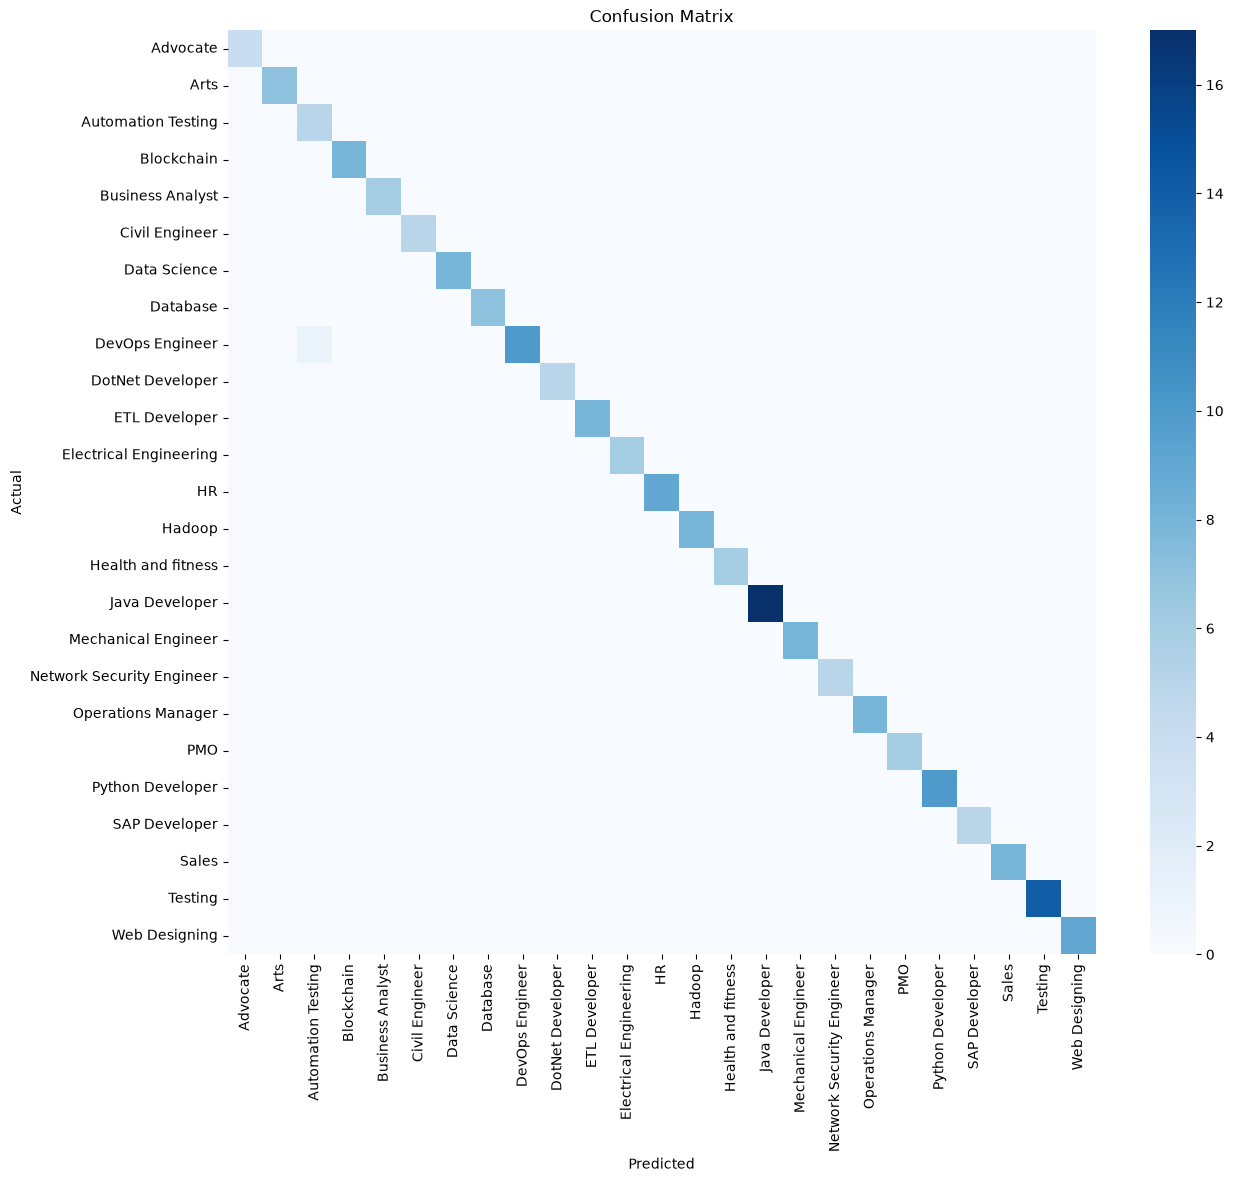

In [7]:
cm = confusion_matrix(y_test, predictions)

plt.figure(figsize=(14,12))

sns.heatmap(
    cm,
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [8]:
accuracy = np.mean(predictions == y_test)

print(f"Overall Accuracy : {accuracy:.4f}")

Overall Accuracy : 0.9948


In [9]:
feature_names = tfidf.get_feature_names_out()

coef = model.coef_

print("Number of Features:", len(feature_names))

Number of Features: 5000


In [10]:
category_index = 0

top_features = np.argsort(coef[category_index])[-20:]

for feature in reversed(top_features):
    print(feature_names[feature])

advocate
legal
law
court
tax
criminal
maharashtra board
matter
district
income
drafting
university
practice
chennai
return
authority
mumbai university
solapur
bcom
account


In [12]:
def predict_resume_category(resume_text):
    
    cleaned_text = clean_resume(resume_text)

    vector = tfidf.transform([cleaned_text])

    prediction = model.predict(vector)

    category = label_encoder.inverse_transform(prediction)

    return category[0]